In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
integrated = []
integrated_refs = {}
integrated_parameters = {}
for ref in ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    complete_only=True,
):
    status = ds.inspect_artifact(ref)
    parameters = status.parameters or {}
    method = parameters["method"]
    if method in integrated_refs:
        raise RuntimeError(f"Expected one complete {method!r} graph")
    integrated_refs[method] = ref
    integrated_parameters[method] = parameters
    integrated.append(
        {
            "method": method,
            "artifact": ref.artifact_id[:12],
        }
    )
pd.DataFrame(integrated).sort_values("method", ignore_index=True)

,method,artifact
0,snn,204243e7c6e1
1,wnn,77c26c919658


In [3]:
baseline = ds.pipeline.open(label="docs_default")
graph_names = {
    baseline["connectivity_map"]: "RNA",
    integrated_refs["snn"]: "SNN",
    integrated_refs["wnn"]: "WNN",
}
partition_refs = {"RNA": baseline["clusters"]}
partition_candidates = ds.list_artifacts(
    kind="cluster_labels",
    scope="datastore",
    complete_only=True,
)
for assay in ("RNA", "ADT"):
    partition_candidates.extend(
        ds.list_artifacts(
            kind="cluster_labels",
            from_assay=assay,
            complete_only=True,
        )
    )
for ref in partition_candidates:
    graph_value = (ds.inspect_artifact(ref).inputs or {}).get("graph")
    if not isinstance(graph_value, dict):
        continue
    graph_ref = scarf.ArtifactRef.from_dict(graph_value)
    name = graph_names.get(graph_ref)
    if name is None and ref.assay == "ADT":
        name = "ADT"
    if name is None:
        continue
    if name in partition_refs and partition_refs[name] != ref:
        raise RuntimeError(f"Expected one complete {name!r} partition")
    partition_refs[name] = ref

expected_partitions = {"RNA", "ADT", "SNN", "WNN"}
if set(partition_refs) != expected_partitions:
    raise RuntimeError("The CITE-seq snapshot is missing a required partition")

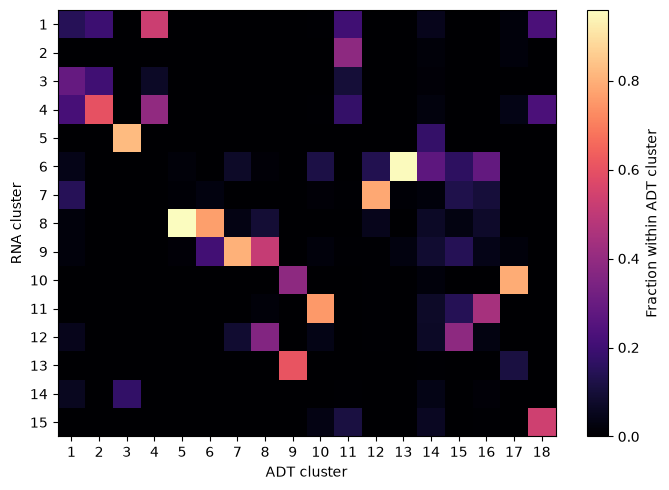

In [4]:
overlap = pd.crosstab(
    ds.cells.fetch("RNA_leiden_cluster"),
    ds.cells.fetch("ADT_leiden_cluster"),
    normalize="columns",
)

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(overlap.to_numpy(), aspect="auto", cmap="magma")
ax.set(
    xlabel="ADT cluster",
    ylabel="RNA cluster",
    xticks=np.arange(overlap.shape[1]),
    yticks=np.arange(overlap.shape[0]),
    xticklabels=overlap.columns,
    yticklabels=overlap.index,
)
fig.colorbar(image, ax=ax, label="Fraction within ADT cluster")
fig.tight_layout()

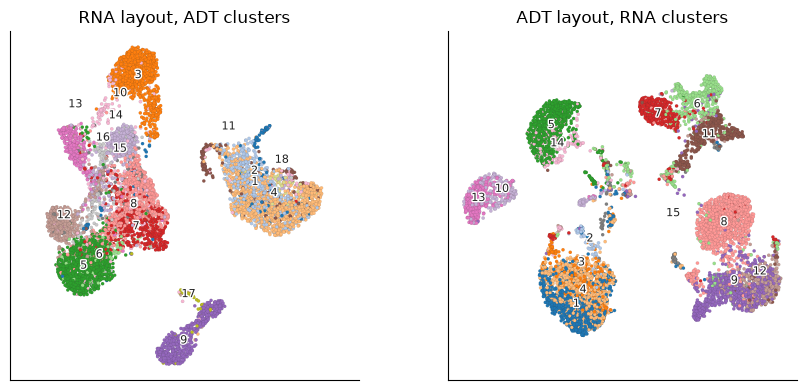

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
cross_panels = (
    ("RNA layout, ADT clusters", "RNA_UMAP", "ADT_leiden_cluster"),
    ("ADT layout, RNA clusters", "ADT_UMAP", "RNA_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, cross_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

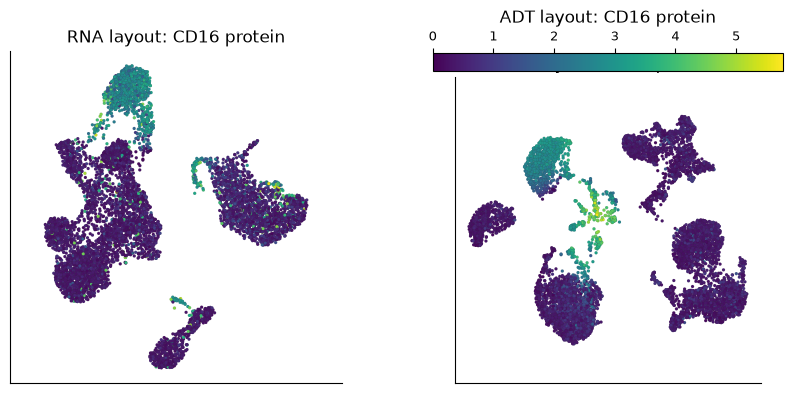

In [6]:
def compare_signal(feature, assay, label, layouts):
    figure, axes = plt.subplots(1, 2, figsize=(9, 4))
    for index, (axis, (layout_label, layout_key)) in enumerate(
        zip(axes, layouts, strict=True)
    ):
        ds.plots.embedding(
            layout_key=layout_key,
            color_by=feature,
            from_assay=assay,
            point_size=5,
            show_legend=index == 1,
            show_titles=False,
            target=axis,
            show=False,
        )
        axis.set_title(f"{layout_label}: {label}")
    # Top colorbars occupy the title slot; label the colorbar axes instead.
    right_title = f"{layouts[-1][0]}: {label}"
    for colorbar_axis in set(figure.axes) - set(axes):
        colorbar_axis.set_title(right_title)
        colorbar_axis.set_xlabel("")
        colorbar_axis.set_ylabel("")
    figure.tight_layout()
    return figure


modality_layouts = (
    ("RNA layout", "RNA_UMAP"),
    ("ADT layout", "ADT_UMAP"),
)
compare_signal(
    "CD16_TotalSeqB",
    "ADT",
    "CD16 protein",
    modality_layouts,
);

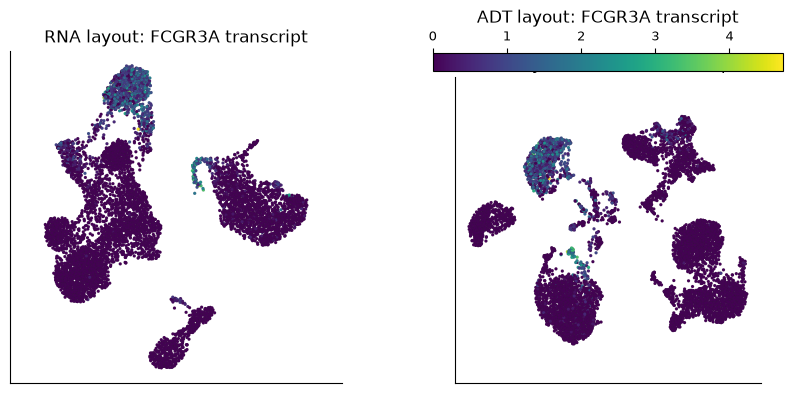

In [7]:
compare_signal(
    "FCGR3A",
    "RNA",
    "FCGR3A transcript",
    modality_layouts,
);

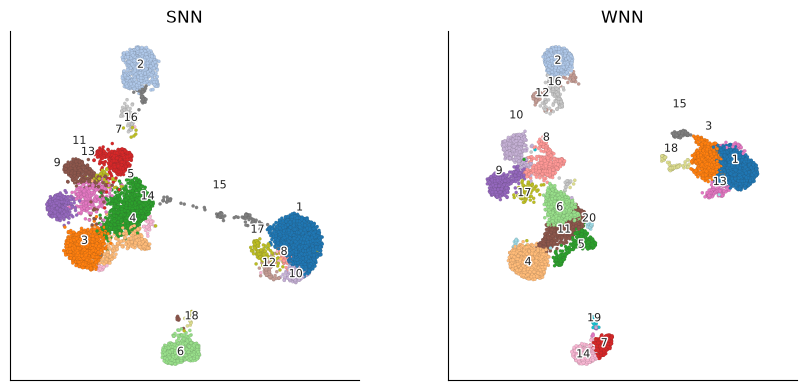

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
integration_panels = (
    ("SNN", "RNA+ADT_UMAP", "RNA+ADT_leiden_cluster"),
    ("WNN", "RNA+ADT_wnn_UMAP", "RNA+ADT_wnn_leiden_cluster"),
)
for axis, (title, layout_key, color_by) in zip(
    axes, integration_panels, strict=True
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=color_by,
        legend_loc="on_data",
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

In [9]:
concordance_rows = []
for first, second in combinations(partition_refs, 2):
    concordance_rows.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                partition_refs[first],
                partition_refs[second],
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                partition_refs[first],
                partition_refs[second],
                metric="nmi",
            ),
        }
    )
pd.DataFrame(concordance_rows)

,comparison,ARI,NMI
0,RNA vs WNN,0.657410,0.769348
1,RNA vs SNN,0.610360,0.739837
2,RNA vs ADT,0.557279,0.663471
3,WNN vs SNN,0.701547,0.817274
4,WNN vs ADT,0.701236,0.772867
5,SNN vs ADT,0.718177,0.808475


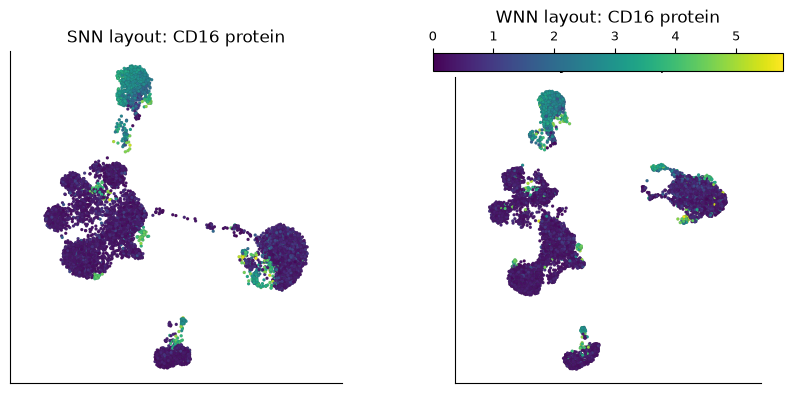

In [10]:
integrated_layouts = (
    ("SNN layout", "RNA+ADT_UMAP"),
    ("WNN layout", "RNA+ADT_wnn_UMAP"),
)
compare_signal(
    "CD16_TotalSeqB",
    "ADT",
    "CD16 protein",
    integrated_layouts,
);

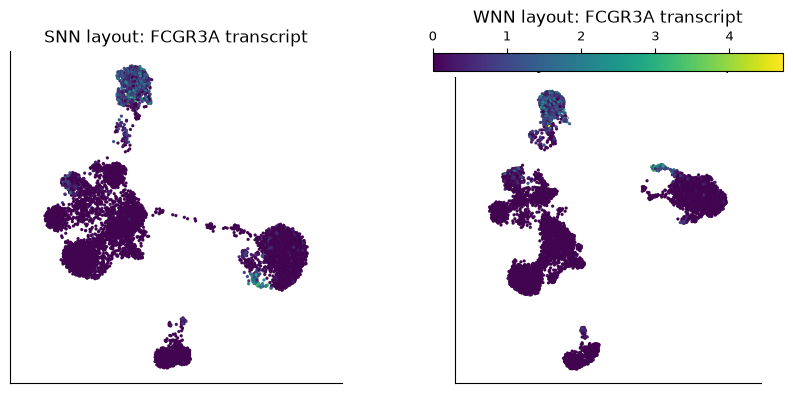

In [11]:
compare_signal(
    "FCGR3A",
    "RNA",
    "FCGR3A transcript",
    integrated_layouts,
);

In [12]:
weight_values = np.asarray(
    ds.load_artifact(integrated_refs["wnn"])["modality_weights"][:],
    dtype=np.float64,
)
weight_columns = [
    f"{assay} weight"
    for assay in integrated_parameters["wnn"]["assays"]
]
weight_frame = pd.DataFrame(
    weight_values,
    columns=weight_columns,
)
pd.Series(
    {
        "all finite": bool(np.isfinite(weight_values).all()),
        "all non-negative": bool((weight_values >= 0).all()),
        "maximum row-sum error": float(
            np.max(np.abs(weight_values.sum(axis=1) - 1))
        ),
    }
)

all finite               True
all non-negative         True
maximum row-sum error     0.0
dtype: object

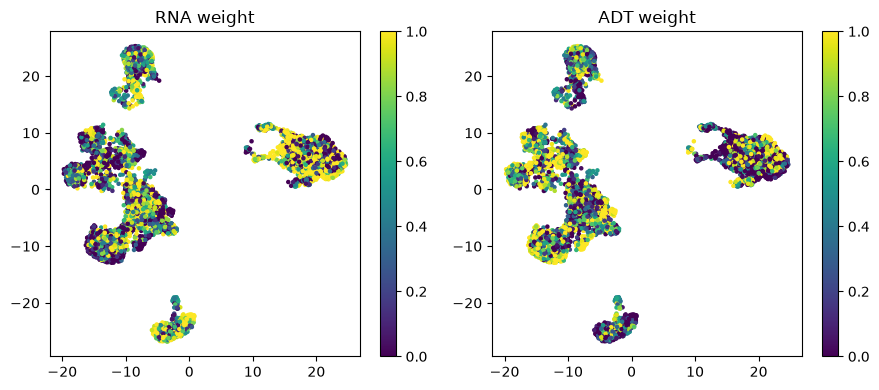

In [13]:
wnn_layout = ds.cells.to_pandas_dataframe(
    ["RNA+ADT_wnn_UMAP1", "RNA+ADT_wnn_UMAP2"],
    key="I",
)
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, title in zip(axes, weight_frame.columns, strict=True):
    points = axis.scatter(
        wnn_layout["RNA+ADT_wnn_UMAP1"],
        wnn_layout["RNA+ADT_wnn_UMAP2"],
        c=weight_frame[title],
        s=5,
    )
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()

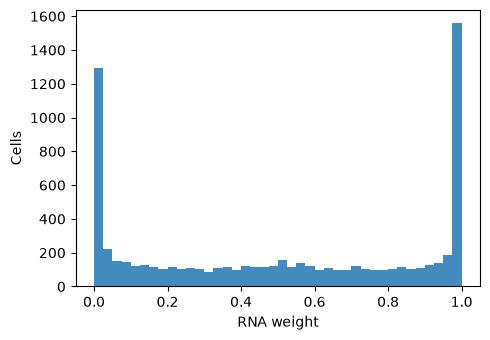

In [14]:
figure, axis = plt.subplots(figsize=(5, 3.5))
axis.hist(weight_frame["RNA weight"], bins=40, color="C0", alpha=0.85)
axis.set(xlabel="RNA weight", ylabel="Cells")
figure.tight_layout()

In [15]:
rna_clusters = pd.Series(
    ds.cells.fetch("RNA_leiden_cluster", key="I")
)
adt_clusters = pd.Series(
    ds.cells.fetch("ADT_leiden_cluster", key="I")
)
dominant_rna_by_adt = overlap.idxmax(axis=0)
weight_frame["RNA-ADT overlap"] = np.where(
    rna_clusters == adt_clusters.map(dominant_rna_by_adt),
    "dominant overlap",
    "other overlap",
)
weight_frame.groupby("RNA-ADT overlap").agg(["count", "mean", "median"])

RNA weight                     ADT weight                    
                      count      mean    median      count      mean    median
RNA-ADT overlap                                                               
dominant overlap       5039  0.485877  0.483734       5039  0.514123  0.516266
other overlap          2360  0.566473  0.631971       2360  0.433527  0.368029